In [1]:
# === CELL 1: Imports y dependencias ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import gymnasium as gym
from gymnasium import spaces

try:
    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import DummyVecEnv
except ImportError:
    print("Instala stable-baselines3 antes de ejecutar este notebook.")

In [2]:
# === CELL 2: Generar CSV de ejemplo si no existe ===
# csv_path = 'ndvi_series.csv'
# if not os.path.exists(csv_path):
#     print("No se encontró CSV, generando serie sintética de NDVI...")
#     dates = pd.date_range(start='2005-01-01', end='2024-12-31', freq='16D')
#     ndvi = 0.4 + 0.3*np.sin(2*np.pi*(np.arange(len(dates))/23)) + 0.05*np.random.randn(len(dates))
#     df = pd.DataFrame({'time': dates, 'ndvi': ndvi})
#     df.to_csv(csv_path, index=False)
# else:
#     df = pd.read_csv(csv_path, parse_dates=['time'])

# df['ndvi'] = df['ndvi'].astype(float)
# print("Serie cargada. Longitud:", len(df))
# df.head()

### Levanto series verdaderas de NDVI

In [3]:
filename = 'sitio1_deforestacion_train.csv'
dataFolder = 'SERIES_NUEVAS/'
df = pd.read_csv(dataFolder+filename)

In [4]:
df.columns.values

array(['Unnamed: 0', 'lon', 'lat', 'sitio', 'anio', 'mes', 'nubes',
       '2000-02-18', '2000-03-05', '2000-03-21', '2000-04-06',
       '2000-04-22', '2000-05-08', '2000-05-24', '2000-06-09',
       '2000-06-25', '2000-07-11', '2000-07-27', '2000-08-12',
       '2000-08-28', '2000-09-13', '2000-09-29', '2000-10-15',
       '2000-10-31', '2000-11-16', '2000-12-02', '2000-12-18',
       '2001-01-01', '2001-01-17', '2001-02-02', '2001-02-18',
       '2001-03-06', '2001-03-22', '2001-04-07', '2001-04-23',
       '2001-05-09', '2001-05-25', '2001-06-10', '2001-06-26',
       '2001-07-12', '2001-07-28', '2001-08-13', '2001-08-29',
       '2001-09-14', '2001-09-30', '2001-10-16', '2001-11-01',
       '2001-11-17', '2001-12-03', '2001-12-19', '2002-01-01',
       '2002-01-17', '2002-02-02', '2002-02-18', '2002-03-06',
       '2002-03-22', '2002-04-07', '2002-04-23', '2002-05-09',
       '2002-05-25', '2002-06-10', '2002-06-26', '2002-07-12',
       '2002-07-28', '2002-08-13', '2002-08-29', '

Ploteo eventos de deforestacion

In [6]:
ndviDataStart = 7
testPixel = np.arange(0,20)

### reconstruyo vector fechas

In [7]:
fechas = pd.to_datetime(df.columns[ndviDataStart:])


### Incluyo fecha deforestacion

In [8]:
df['fechaDef'] = pd.to_datetime({
    'year': df['anio'].astype(int),
    'month': df['mes'].astype(int),
    'day': 1
})

In [9]:
col = df.pop('fechaDef')
df.insert(1, 'fechaDef', col)

In [10]:
df

,Unnamed: 0,fechaDef,lon,lat,sitio,anio,mes,nubes,2000-02-18,2000-03-05,...,2018-05-25,2018-06-10,2018-06-26,2018-07-12,2018-07-28,2018-08-13,2018-08-29,2018-09-14,2018-09-30,2018-10-16
0,0,2012-06-01,-63.090370,-25.042652,1.0,2012.0,6.0,0.0,0.4052,0.366167,...,0.2710,0.1923,0.2186,0.1878,0.1518,0.1496,0.1639,0.15950,0.1634,0.3735
1,1,2012-06-01,-63.088070,-25.042652,1.0,2012.0,6.0,0.0,0.4098,0.371700,...,0.2710,0.1935,0.2186,0.1777,0.1468,0.1597,0.1745,0.18590,0.1543,0.3981
2,2,2012-06-01,-63.085771,-25.042652,1.0,2012.0,6.0,0.0,0.4156,0.376000,...,0.2879,0.2050,0.2131,0.1896,0.1546,0.1597,0.1620,0.15510,0.1543,0.3981
3,4,2012-06-01,-63.081172,-25.042652,1.0,2012.0,6.0,0.0,0.4236,0.387333,...,0.2938,0.1944,0.2257,0.1864,0.1557,0.1622,0.1518,0.14760,0.1630,0.4007
4,5,2012-06-01,-63.078872,-25.042652,1.0,2012.0,6.0,0.0,0.4252,0.388200,...,0.2822,0.1773,0.2205,0.1724,0.1429,0.1555,0.1588,0.14520,0.1795,0.3924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4605,5757,2013-08-01,-62.970028,-25.392651,1.0,2013.0,8.0,0.0,0.3661,0.366100,...,0.2491,0.2040,0.2330,0.1758,0.1567,0.1599,0.1482,0.16100,0.1483,0.3382
4606,5758,2013-08-01,-62.968809,-25.394735,1.0,2013.0,8.0,0.0,0.3370,0.337000,...,0.2811,0.2147,0.2321,0.1984,0.1659,0.1639,0.1564,0.17860,0.1653,0.3339
4607,5759,2013-08-01,-62.969896,-25.396818,1.0,2013.0,8.0,0.0,0.4503,0.370950,...,0.2830,0.2061,0.2355,0.1951,0.1620,0.1643,0.1542,0.15950,0.1648,0.3430
4608,5761,2013-08-01,-62.968677,-25.398901,1.0,2013.0,8.0,0.0,0.4493,0.376150,...,0.2632,0.2074,0.2225,0.1851,0.1586,0.1520,0.1678,0.16405,0.1603,0.3377


In [11]:
ndviDataStart+=1

### fecha de deforestacion

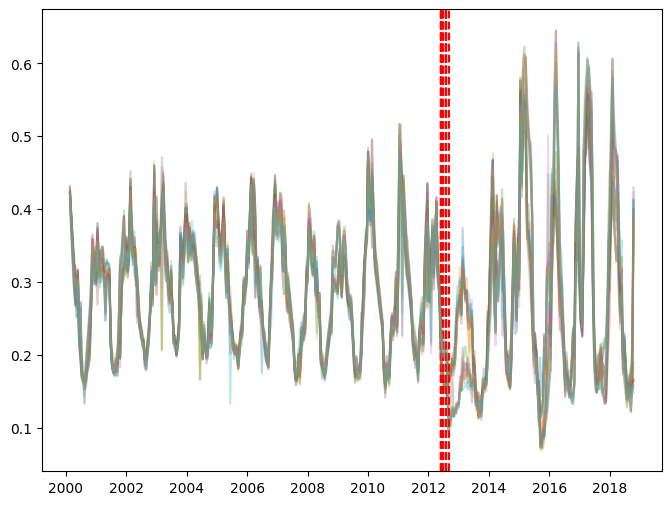

In [12]:
from datetime import datetime

fig, ax = plt.subplots(figsize=(8, 6))

df2 = pd.DataFrame()
df2['fechas'] = fechas

for pixel in testPixel:

    # deforestationDate = datetime(int(df['anio'].iloc[pixel]), int(df['mes'].iloc[pixel]), 1)
    deforestationDate = df['fechaDef'].iloc[pixel]
    ndvi = df.iloc[pixel, ndviDataStart:].values

    df2[pixel] = ndvi

    ax.plot(fechas, ndvi, alpha = 0.3)
    ax.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')

### Normalizo

In [13]:
# === CELL 3: Preprocesamiento y split ===
# Normalización [-1,1]
ndvi = df2.iloc[:,1:].values
minv, maxv = ndvi.min(), ndvi.max()
def normalize(x): return 2*(x - minv)/(maxv - minv) - 1
def denormalize(z): return ((z+1)/2*(maxv - minv)) + minv

# df['ndvi_norm'] = normalize(ndvi)
ndvi_norm = df2.iloc[:,1:].apply(normalize)

### Split (antes y despues de deforestar)

In [14]:
mask = (fechas.year == deforestationDate.year) & (fechas.month == deforestationDate.month)

In [15]:
deforestationDate = np.where(mask)[0][0]

In [16]:
# Train-test split 80/20
# n = len(df)
# n_train = int(0.8*n)
# train_df = df.iloc[:n_train].reset_index(drop=True)
# test_df = df.iloc[n_train:].reset_index(drop=True)

# print("Train:", len(train_df), " Test:", len(test_df))

# ax.plot(fechas[:deforestationDate], ndvi[:deforestationDate], alpha = 0.3)

train_df = ndvi_norm.iloc[:deforestationDate].reset_index(drop=True)
test_df = ndvi_norm.iloc[deforestationDate:].reset_index(drop=True)

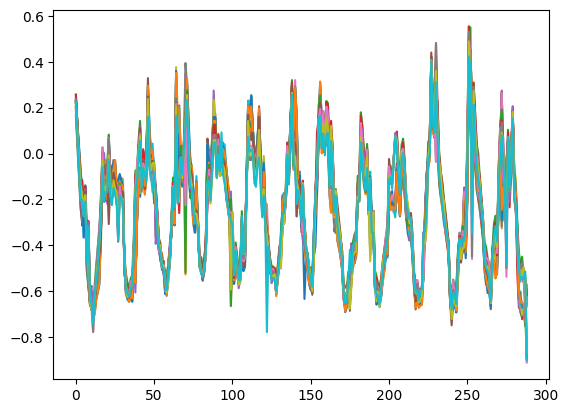

In [17]:
plt.plot(train_df)

In [18]:
train_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.16603,0.182008,0.202154,0.229941,0.235498,0.225773,0.202154,0.202154,0.22091,0.226468,0.226468,0.242445,0.256339,0.256339,0.237235,0.228899,0.195554,0.218479,0.225773,0.224383
1,0.03045,0.04967,0.064606,0.103971,0.106982,0.104434,0.102119,0.100961,0.114623,0.122265,0.129675,0.126664,0.125043,0.12238,0.117518,0.113813,0.072016,0.085794,0.104898,0.081278
2,-0.105129,-0.082668,-0.072942,-0.021998,-0.021535,-0.016904,0.002084,-0.000232,0.008336,0.018062,0.032882,0.010883,-0.006252,-0.011578,-0.0022,-0.001274,-0.051523,-0.046891,-0.015978,-0.061827
3,-0.240709,-0.215005,-0.21049,-0.147968,-0.150052,-0.138242,-0.097951,-0.101424,-0.097951,-0.086141,-0.063911,-0.104898,-0.137548,-0.145537,-0.121917,-0.11636,-0.175061,-0.179576,-0.136853,-0.204932
4,-0.288989,-0.246961,-0.306704,-0.313651,-0.299757,-0.246961,-0.241403,-0.23133,-0.226815,-0.139632,-0.180618,-0.22091,-0.122959,-0.115318,-0.166725,-0.168809,-0.215353,-0.165335,-0.184092,-0.202154
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284,-0.670719,-0.692949,-0.692949,-0.604029,-0.631469,-0.65752,-0.672108,-0.622786,-0.611671,-0.655089,-0.63008,-0.64189,-0.490101,-0.499132,-0.52553,-0.549844,-0.559917,-0.499132,-0.538729,-0.551928
285,-0.683918,-0.690518,-0.715874,-0.721778,-0.707885,-0.688781,-0.699548,-0.700938,-0.700938,-0.673498,-0.656131,-0.651962,-0.449809,-0.508163,-0.508163,-0.508857,-0.500521,-0.477596,-0.534213,-0.538034
286,-0.662383,-0.664467,-0.671066,-0.676276,-0.677666,-0.667246,-0.660646,-0.682529,-0.656478,-0.662035,-0.674192,-0.656825,-0.539076,-0.543244,-0.534908,-0.562695,-0.542202,-0.522404,-0.495311,-0.547412
287,-0.732199,-0.752345,-0.752345,-0.725599,-0.725599,-0.74123,-0.731851,-0.731851,-0.720389,-0.712747,-0.678361,-0.729767,-0.695033,-0.55818,-0.55818,-0.543939,-0.632859,-0.529698,-0.529698,-0.514415


#### Definicion listas de train y test

In [19]:
series_list = [
    train_df[0].values,
    train_df[1].values,
    train_df[2].values,
    train_df[3].values,
    train_df[4].values,
    train_df[5].values,
    train_df[6].values,
    train_df[7].values,
    train_df[8].values,
    train_df[9].values,
    train_df[10].values,
    train_df[11].values,
    train_df[12].values,
    train_df[13].values,
    train_df[14].values,
    train_df[15].values,
    train_df[16].values,
    train_df[17].values,
    train_df[18].values,
    train_df[19].values
]

In [20]:
test_series = [
    test_df[0].values,
    test_df[1].values,
    test_df[2].values,
    test_df[3].values,
    test_df[4].values,
    test_df[5].values,
    test_df[6].values,
    test_df[7].values,
    test_df[8].values,
    test_df[9].values,
    test_df[10].values,
    test_df[11].values,
    test_df[12].values,
    test_df[13].values,
    test_df[14].values,
    test_df[15].values,
    test_df[16].values,
    test_df[17].values,
    test_df[18].values,
    test_df[19].values
]

### Definicion Entorno gym.Env para que tome stable_baselines3

In [21]:
# === CELL 4: Definir entorno NDVIEnv ===
class NDVIEnv(gym.Env):
    metadata = {'render.modes': ['human']}

    def __init__(self, series, window=23):
        super().__init__()
        self.actionMin, self.actionMax = -1.5, 1.5
        self.series = np.array(series, dtype=np.float16)
        self.window = window
        self.action_space = spaces.Box(low=self.actionMin, high=self.actionMax, shape=(1,), dtype=np.float16)
        self.observation_space = spaces.Box(low=self.actionMin, high=self.actionMax, shape=(self.window,), dtype=np.float16)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.idx = self.window
        self.done = False
        obs = self.series[self.idx-self.window:self.idx].copy()
        return obs, {}

    def step(self, action):
        pred = float(np.clip(action[0], self.actionMin, self.actionMax))
        true_val = float(self.series[self.idx])
        reward = - (true_val - pred)**2  # negative MSE
        self.idx += 1
        self.done = self.idx >= len(self.series)
        obs = self.series[self.idx-self.window:self.idx].copy() if not self.done else np.zeros(self.window, dtype=np.float16)
        return obs, reward, self.done, False, {}

    def render(self):
        pass

# Prueba del entorno
env = NDVIEnv(train_df.values, window=23)
obs, _ = env.reset()
print("Observación inicial shape:", obs.shape)

Observación inicial shape: (23, 20)


In [23]:
env_fns = [lambda s=s: NDVIEnv(s, window=23) for s in series_list]
vec_env = DummyVecEnv(env_fns)

In [30]:
env_fns[0]().reset()

(array([ 0.166   ,  0.03046 , -0.1051  , -0.2407  , -0.289   , -0.321   ,
        -0.272   , -0.5107  , -0.5825  , -0.654   , -0.669   , -0.684   ,
        -0.6636  , -0.5957  , -0.559   , -0.4675  , -0.318   , -0.1198  ,
        -0.1577  , -0.1967  , -0.1967  ,  0.004864, -0.1779  ],
       dtype=float16),
 {})

In [31]:
vec_env.num_envs

20

In [47]:
# === CELL 5: Entrenamiento PPO ===
# vec_env = DummyVecEnv([lambda: NDVIEnv(train_df['ndvi_norm'].values, window=23)])
model = PPO('MlpPolicy', vec_env, verbose=1, learning_rate=3e-4, batch_size=64)
# Entrena por pocos timesteps para prueba rápida
model.learn(total_timesteps=1000000)
print("Entrenamiento completo")

Using cpu device
------------------------------
| time/              |       |
|    fps             | 70033 |
|    iterations      | 1     |
|    time_elapsed    | 0     |
|    total_timesteps | 40960 |
------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 4277        |
|    iterations           | 2           |
|    time_elapsed         | 19          |
|    total_timesteps      | 81920       |
| train/                  |             |
|    approx_kl            | 0.037870456 |
|    clip_fraction        | 0.233       |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.26       |
|    explained_variance   | 0.00243     |
|    learning_rate        | 0.0003      |
|    loss                 | 8.51        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0282     |
|    std                  | 0.845       |
|    value_loss           | 17.8        |
----------

In [ ]:
# obs = vec_env.reset()
# total_rewards = np.zeros(len(series_list))

# for t in range(500):  # un episodio típico
#     action, _ = model.predict(obs)
#     obs, rewards, dones, infos = vec_env.step(action)
#     total_rewards += rewards
#     if np.all(dones):
#         break

# print("Recompensa promedio por serie:", total_rewards / t)

In [33]:
# from stable_baselines3.common.vec_env import DummyVecEnv

test_env = DummyVecEnv([lambda s=s: NDVIEnv(s, window=23) for s in test_series])
obs = test_env.reset()

done = [False]
preds = []
rewards = []

while not all(done):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = test_env.step(action)
    preds.append(action)
    rewards.append(reward)

In [35]:
obs.shape

(20, 23)

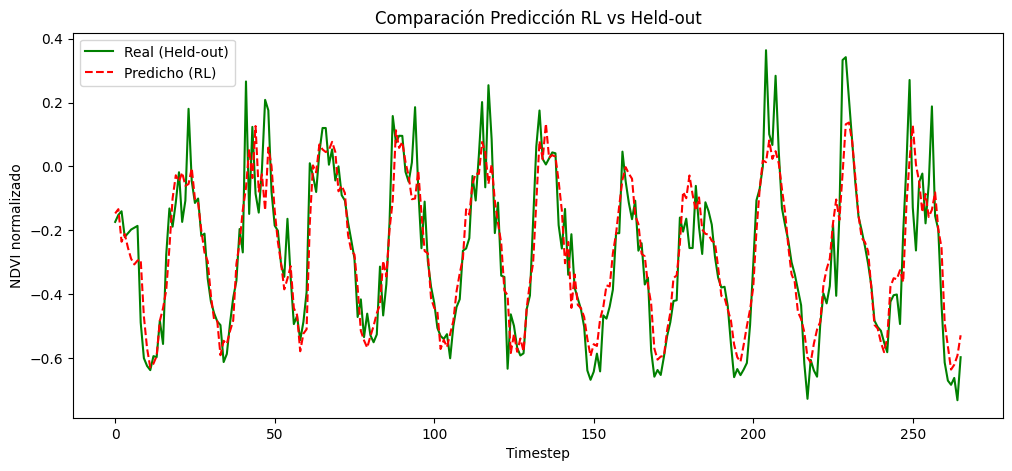

In [50]:
# Si test_env es un entorno simple (no DummyVecEnv)

#test_env = NDVIEnv(test_series[0], window=23) # evaluacion posta
test_env = NDVIEnv(series_list[0], window=23)
obs, _ = test_env.reset()

preds = []
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = test_env.step(action)
    preds.append(action.item())

# Valores reales
true_vals = test_env.series[test_env.window:test_env.window + len(preds)]

preds = np.array(preds)

plt.figure(figsize=(12,5))
plt.plot(true_vals, label='Real (Held-out)', color='green')
# plt.plot(series_list[0], label='Real (Held-out)', color='blue')

plt.plot(preds, label='Predicho (RL)', color='red', linestyle='--')
plt.title("Comparación Predicción RL vs Held-out")
plt.xlabel("Timestep")
plt.ylabel("NDVI normalizado")
plt.legend()
plt.show()

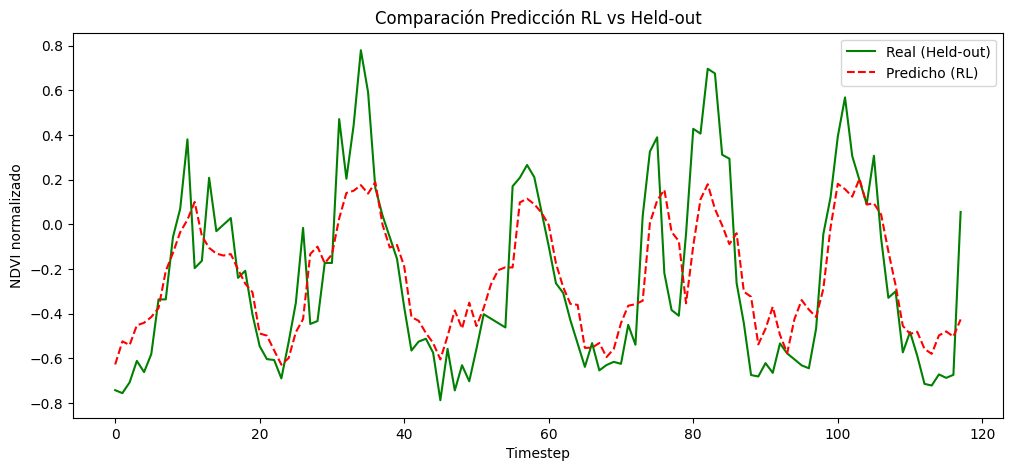

In [51]:
# Si test_env es un entorno simple (no DummyVecEnv)

#test_env = NDVIEnv(test_series[0], window=23) # evaluacion posta
test_env = NDVIEnv(test_series[0], window=23)
obs, _ = test_env.reset()

preds = []
done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = test_env.step(action)
    preds.append(action.item())

# Valores reales
true_vals = test_env.series[test_env.window:test_env.window + len(preds)]

preds = np.array(preds)

plt.figure(figsize=(12,5))
plt.plot(true_vals, label='Real (Held-out)', color='green')
# plt.plot(series_list[0], label='Real (Held-out)', color='blue')

plt.plot(preds, label='Predicho (RL)', color='red', linestyle='--')
plt.title("Comparación Predicción RL vs Held-out")
plt.xlabel("Timestep")
plt.ylabel("NDVI normalizado")
plt.legend()
plt.show()

Pasa lo que esperaba: con lo que aprende de bosque es muy malo vegetacion

In [ ]:
# # === CELL 6: Evaluación ===
# test_env = NDVIEnv(test_df.values, window=23)
# obs, _ = test_env.reset()
# preds = []
# trues = []
# done = False

# while not done:
#     action, _ = model.predict(obs, deterministic=True)
#     obs, reward, done, truncated, info = test_env.step(action)
#     preds.append(float(np.clip(action[0], -1.5, 1.5)))
#     trues.append(float(test_env.series[test_env.idx-1]))

# preds_denorm = denormalize(np.array(preds))
# trues_denorm = denormalize(np.array(trues))

# #from sklearn.metrics import mean_squared_error
# rmse = ((trues_denorm - preds_denorm)**2).mean()**0.5
# print(f"RMSE test: {rmse:.4f}")

# plt.figure(figsize=(12,4))
# plt.plot(test_df['time'].iloc[10:10+len(trues_denorm)], trues_denorm, label='NDVI real')
# plt.plot(test_df['time'].iloc[10:10+len(preds_denorm)], preds_denorm, label='Predicción RL')
# plt.legend()
# plt.title('NDVI real vs predicción (test)')
# plt.show()

# Pruebo version quasi-supervisada?

- **setup**: tomas dos vectores de entrada: el ndvi y un vector categorico que le indica el landcover (0: bosque, 1: no-bosque)
- **idea**: la ieda es que el sistema tenga dos estados, y aprende a seguir la serie de tiempo en cada uno de ellos.
- **como se usa**: si entrena, se puede cambiar el input de 0 a 1 a ver a que modelo ajusta mejor